# Story Writing Benchmark — 2. Cost Analysis

## Setup

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams["figure.dpi"] = 120

RESULTS_DIR   = Path("../dataset/results")
LOGS_DIR      = Path("../logs")
BASELINE_FILE = "claude_sonnet_4.6_result.csv"

GPU_RATE_LOW  = 2.0   # $/hr (H100)
GPU_RATE_HIGH = 3.5
CLAUDE_PRICE_INPUT  = 3.0   # $/1M input tokens
CLAUDE_PRICE_OUTPUT = 15.0  # $/1M output tokens

SCORE_MIN, SCORE_MAX = 0, 5

ALL_CATEGORIES = [
    "Grammar, Spelling, and Punctuation Quality",
    "Clarity and Understandability",
    "Logical Connection Between Events and Ideas",
    "Scene Construction and Purpose",
    "Internal Consistency",
    "Character Consistency",
    "Character Motivation and Actions",
    "Sentence Pattern Variety",
    "Avoidance of Clichés and Overused Phrases",
    "Natural Dialogue",
    "Avoidance of Predictable Narrative Tropes",
    "Character Depth and Dimensionality",
    "Realistic Character Interactions",
    "Ability to Hold Reader Interest",
    "Satisfying Plot Resolution",
]
ALL_COLS = [f"{c}_score" for c in ALL_CATEGORIES]
KEYS     = ["index", "prompt_id", "model"]

def pretty_model(stem: str) -> str:
    return stem.replace("_swb_result", "").replace("_result", "")

## Cost analysis

Computes throughput (tok/s) and effective cost per 1M tokens from inference logs.

$$\text{Throughput} = \frac{\sum \text{total\_tokens}}{\sum \text{latency\_s}} \qquad \text{Cost}_{1\text{M}} = \frac{10^6}{\text{Throughput} \times 3600} \times \text{Rate}_{\text{GPU}}$$

In [2]:
def parse_log(path: Path) -> dict:
    tot = lat = prompt = completion = n_ok = 0
    with open(path) as f:
        for line in f:
            e = json.loads(line)
            if e.get("status") == "ok":
                tot        += e["total_tokens"]
                lat        += e["latency_ms"] / 1000
                prompt     += e["prompt_tokens"]
                completion += e["completion_tokens"]
                n_ok += 1
    return dict(total_tokens=tot, latency_s=lat,
                prompt_tokens=prompt, completion_tokens=completion, n_ok=n_ok)

# Claude baseline
claude_raw = parse_log(LOGS_DIR / "llm_calls_claude-sonnet-4-6.jsonl")
claude_cost_total = (
    claude_raw["prompt_tokens"]     * CLAUDE_PRICE_INPUT  / 1_000_000
    + claude_raw["completion_tokens"] * CLAUDE_PRICE_OUTPUT / 1_000_000
)
CLAUDE_BLENDED = claude_cost_total / claude_raw["total_tokens"] * 1_000_000

print(f"Claude Sonnet 4.6  |  {claude_raw['n_ok']:,} requests  "
      f"|  blended ${CLAUDE_BLENDED:.2f}/1M tokens")

# Open-source models
cost_rows = []
for log_file in sorted(LOGS_DIR.glob("*.jsonl")):
    if "claude" in log_file.name:
        continue
    raw = parse_log(log_file)
    if raw["latency_s"] == 0:
        continue
    tput     = raw["total_tokens"] / raw["latency_s"]
    cost_low  = (1_000_000 / (tput * 3600)) * GPU_RATE_LOW
    cost_high = (1_000_000 / (tput * 3600)) * GPU_RATE_HIGH
    cost_rows.append(dict(
        model=log_file.stem.replace("llm_calls_", ""),
        n_ok=raw["n_ok"],
        throughput=tput,
        cost_low=cost_low,
        cost_high=cost_high,
        cost_mid=(cost_low + cost_high) / 2,
        reduction_low=CLAUDE_BLENDED / cost_low,
        reduction_high=CLAUDE_BLENDED / cost_high,
    ))

cost_df = pd.DataFrame(cost_rows).sort_values("cost_low").reset_index(drop=True)

disp = cost_df[["model","n_ok","throughput","cost_low","cost_high","reduction_low","reduction_high"]].copy()
disp.columns = ["Model","N (ok)","Throughput (tok/s)","Cost/1M low","Cost/1M high","Reduction low","Reduction high"]
disp["Throughput (tok/s)"] = disp["Throughput (tok/s)"].map("{:.0f}".format)
disp["Cost/1M low"]  = disp["Cost/1M low"].map("${:.3f}".format)
disp["Cost/1M high"] = disp["Cost/1M high"].map("${:.3f}".format)
disp["Reduction low"]  = disp["Reduction low"].map("{:.1f}x".format)
disp["Reduction high"] = disp["Reduction high"].map("{:.1f}x".format)
display(disp)

Claude Sonnet 4.6  |  3,570 requests  |  blended $4.60/1M tokens


,Model,N (ok),Throughput (tok/s),Cost/1M low,Cost/1M high,Reduction low,Reduction high
0,Llama-3.2-3B-Instruct,3945,1755,$0.316,$0.554,14.5x,8.3x
1,NVIDIA-Nemotron-3-Nano-4B-BF16,3480,1383,$0.402,$0.703,11.4x,6.5x
2,gemma-4-E2B-it,3480,1344,$0.413,$0.723,11.1x,6.4x
3,Qwen3-4B-Instruct-2507,3480,1191,$0.467,$0.817,9.9x,5.6x
4,Qwen3.5-4B,3480,1036,$0.536,$0.939,8.6x,4.9x
5,gemma-4-E4B-it,3480,869,$0.639,$1.118,7.2x,4.1x


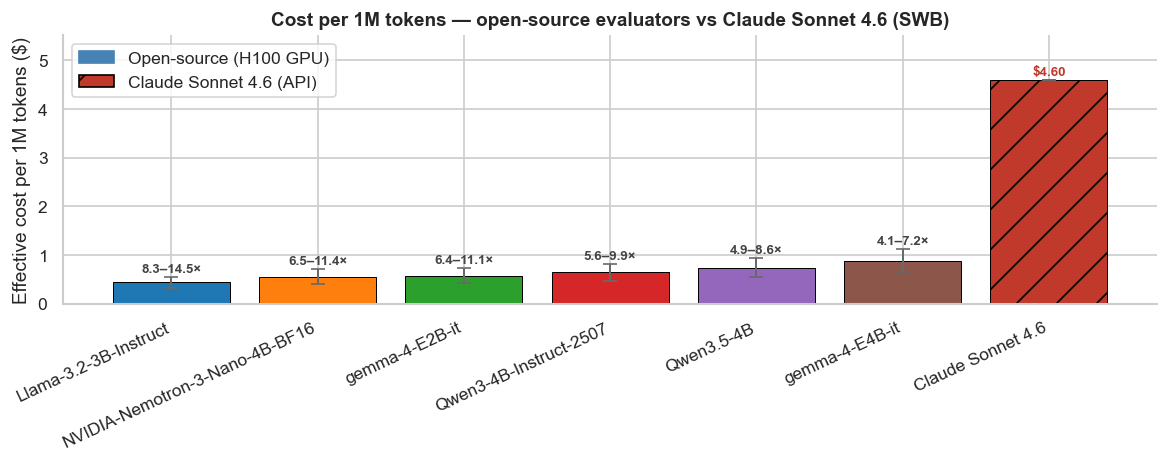

In [3]:
# Bar chart: cost per 1M tokens
fig, ax = plt.subplots(figsize=(10, 4))

labels = cost_df["model"].tolist() + ["Claude Sonnet 4.6"]
mids   = cost_df["cost_mid"].tolist() + [CLAUDE_BLENDED]
errs   = ((cost_df["cost_high"] - cost_df["cost_low"]) / 2).tolist() + [0]
colors = list(sns.color_palette("tab10", n_colors=len(cost_df))) + ["#c0392b"]

x = np.arange(len(labels))
bars = ax.bar(x, mids, yerr=errs, capsize=4, color=colors,
              edgecolor="black", linewidth=0.6,
              error_kw=dict(elinewidth=1.2, ecolor="dimgrey"),
              hatch=[""] * len(cost_df) + ["/"])

for bar, mid, err, rl, rh in zip(
        bars, cost_df["cost_mid"], (cost_df["cost_high"]-cost_df["cost_low"])/2,
        cost_df["reduction_low"], cost_df["reduction_high"]):
    ax.text(bar.get_x() + bar.get_width()/2, mid + err + 0.04,
            f"{rh:.1f}–{rl:.1f}×", ha="center", va="bottom", fontsize=8, fontweight="bold", color="#444")

ax.text(bars[-1].get_x() + bars[-1].get_width()/2, CLAUDE_BLENDED + 0.04,
        f"${CLAUDE_BLENDED:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold", color="#c0392b")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Effective cost per 1M tokens ($)")
ax.set_ylim(0, CLAUDE_BLENDED * 1.2)
ax.set_title("Cost per 1M tokens — open-source evaluators vs Claude Sonnet 4.6 (SWB)",
             fontweight="bold")
ax.legend(handles=[
    mpatches.Patch(color="steelblue", label="Open-source (H100 GPU)"),
    mpatches.Patch(facecolor="#c0392b", hatch="/", edgecolor="black", label="Claude Sonnet 4.6 (API)"),
], loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()